# 1. lorenz

Generate a trajectory of the Lorenz system with `nolitisea.generate.lorenz.lorenz` and visualize the 3-D attractor.

`lorenz` integrates the classical Lorenz equations with `scipy.integrate.solve_ivp` (RK45), discards the first `discard` samples to remove transients, and returns the sampled times together with the phase-space points as an array of shape `(length, 3)`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.generate.lorenz import lorenz

np.random.seed(42)

# Generate a trajectory with default parameters.
t, states = lorenz(length=10000)
print(f"times : shape {t.shape}, t = [{t[0]:.3f}, {t[-1]:.3f}]")
print(f"states: shape {states.shape}")
print(f"first point: {states[0]}")

times : shape (10000,), t = [30.000, 329.971]
states: shape (10000, 3)
first point: [-12.02735593 -18.6368082   22.45196292]


## Save the generated data

Write the trajectory to `./data/lorenz.txt` as a plain-text table with one column per component (`x`, `y`, `z`), matching the data-file convention of the original C programs.

In [ ]:
from pathlib import Path

data_dir = Path("./example/data")
data_dir.mkdir(parents=True, exist_ok=True)

out_path = data_dir / "lorenz.txt"
np.savetxt(
    out_path,
    states,
    fmt="%.8f",
    header=(
        "Lorenz trajectory (sigma=10, beta=8/3, rho=28); "
        "columns: x y z; sample interval 0.03"
    ),
)
print(f"saved {states.shape[0]} samples to {out_path}")

## 3-D attractor

The classic butterfly-shaped Lorenz attractor in phase space:

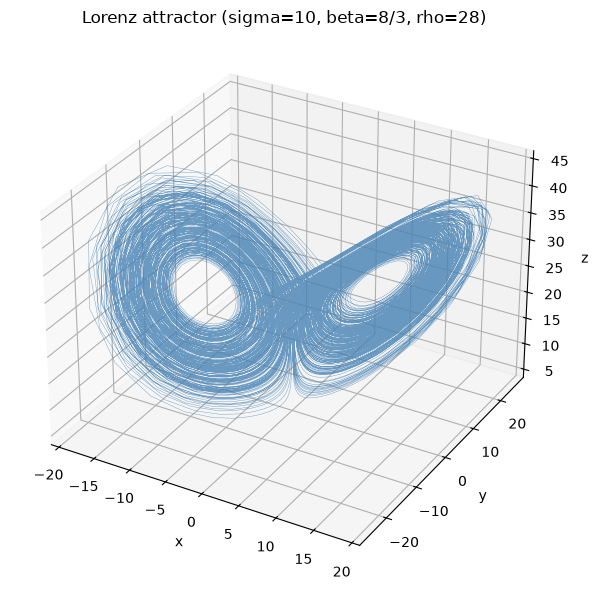

In [2]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.plot(
    states[:, 0], states[:, 1], states[:, 2],
    lw=0.3, color="steelblue", alpha=0.8,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz attractor (sigma=10, beta=8/3, rho=28)")

plt.tight_layout()
plt.show()

## Component time series

Each component of the phase-space vector is a scalar time series that can be fed into the analysis routines of the package:

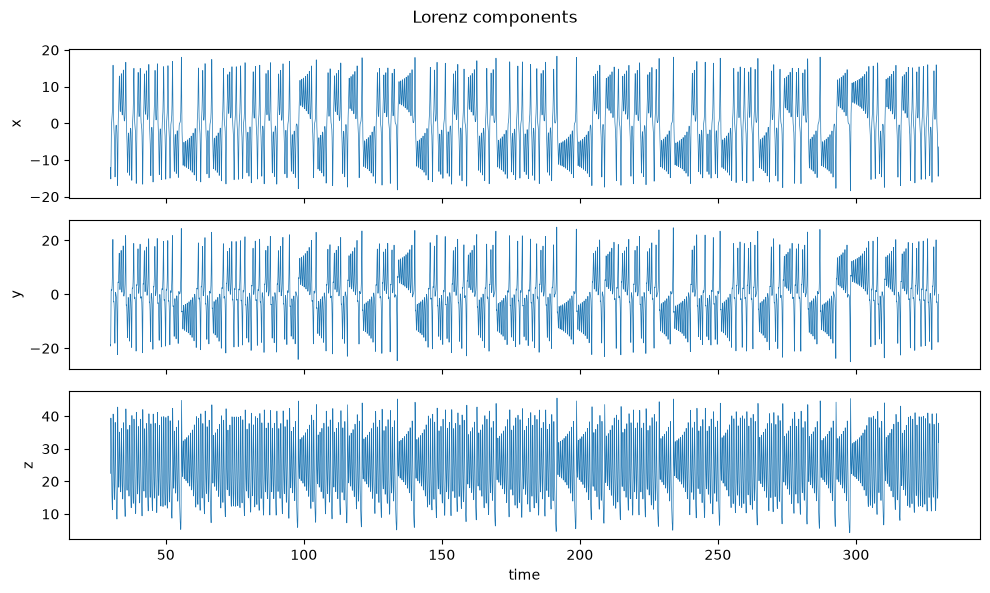

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for ax, name, series in zip(axes, "xyz", states.T):
    ax.plot(t, series, lw=0.5)
    ax.set_ylabel(name)

axes[-1].set_xlabel("time")
fig.suptitle("Lorenz components")

plt.tight_layout()
plt.show()